In [39]:
import numpy as np
import matplotlib.pyplot as plt


def plot_exponential(
    t: np.ndarray,
    r1: complex,
    r2: complex,
    C1: complex,
    C2: complex,
    title: str | None = None,
    tol: float = 1e-12,
):
    """
    Plot the two exponential modes and their sum for a second-order
    constant-coefficient ODE.

    Handles both:
        distinct roots:
            y(t) = C1 exp(r1 t) + C2 exp(r2 t)

        repeated root:
            y(t) = (C1 + C2 t) exp(r t)

    Parameters
    ----------
    t:
        Time array.
    r1, r2:
        Characteristic roots.
    C1, C2:
        Mode coefficients.
    title:
        Optional figure title.
    tol:
        Numerical tolerance for deciding whether roots are repeated.
    """

    t = np.asarray(t)

    repeated_root = np.isclose(r1, r2, atol=tol, rtol=tol)

    if repeated_root:
        r = r1

        y1 = C1 * np.exp(r * t)
        y2 = C2 * t * np.exp(r * t)
        y_sum = y1 + y2

        labels = [
            r"$y_1=C_1e^{rt}$",
            r"$y_2=C_2te^{rt}$",
            r"$y=y_1+y_2$"
        ]

    else:
        y1 = C1 * np.exp(r1 * t)
        y2 = C2 * np.exp(r2 * t)
        y_sum = y1 + y2

        labels = [
            r"$y_1=C_1e^{r_1t}$",
            r"$y_2=C_2e^{r_2t}$",
            r"$y=y_1+y_2$"
        ]

    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(8, 8),
        sharex=True
    )

    signals = [
        (y1, labels[0]),
        (y2, labels[1]),
        (y_sum, labels[2])
    ]

    for ax, (y, label) in zip(axes, signals):
        y_real = np.real(y)
        y_imag = np.imag(y)

        ax.plot(
            t,
            y_real,
            "-",
            linewidth=2,
            label=rf"$\operatorname{{Re}}({label})$"
        )

        if np.any(np.abs(y_imag) > tol):
            ax.plot(
                t,
                y_imag,
                "--",
                linewidth=2,
                label=rf"$\operatorname{{Im}}({label})$"
            )

        ax.axhline(
            0,
            linestyle=":",
            linewidth=1
        )

        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("time [s]")

    if title is not None:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

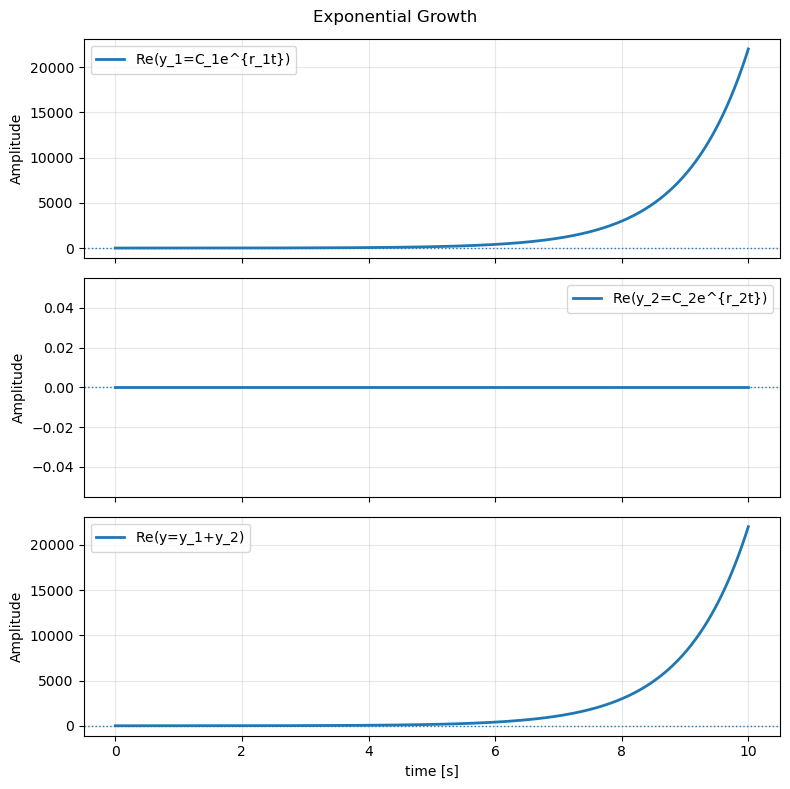

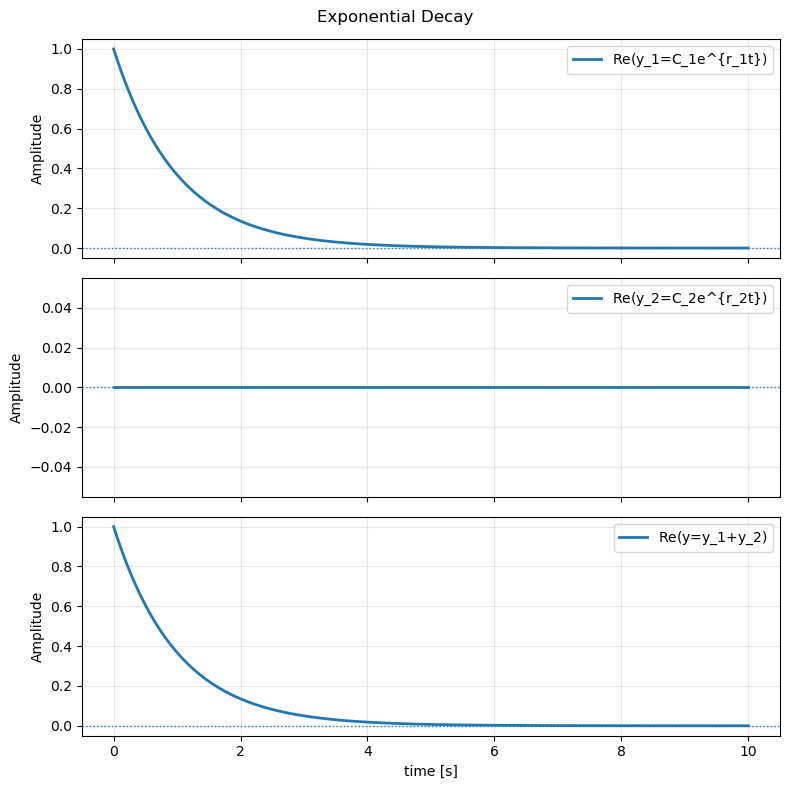

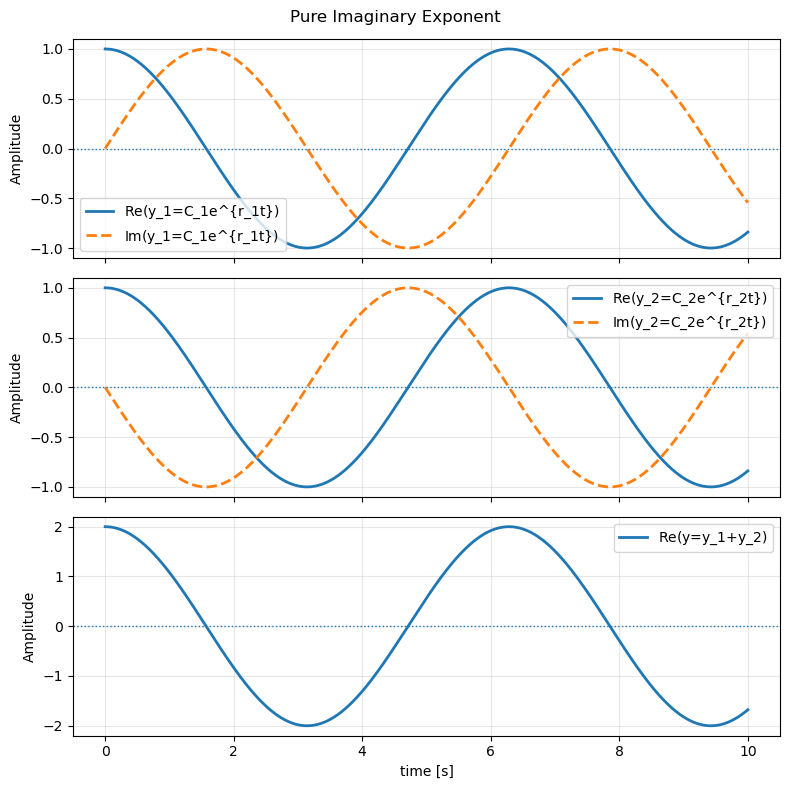

In [40]:
t = np.linspace(0, 10, 1000)

# Exponential growth
plot_exponential(
    t,
    r1=1,
    r2=0,
    C1=1,
    C2=0,
    title="Exponential Growth"
)

# Exponential decay
plot_exponential(
    t,
    r1=-1,
    r2=0,
    C1=1,
    C2=0,
    title="Exponential Decay"
)

# Oscillation from imaginary exponent
plot_exponential(
    t,
    r1=1j,
    r2=-1j,
    C1=1,
    C2=1,
    title="Pure Imaginary Exponent"
)

In [41]:
def solve_2ndOrder_ODE(t, a, b, c, C1=1, C2=1):
    r1, r2 = np.roots([a, b, c])

    # repeated root
    if np.isclose(r1, r2):
        r = r1
        y = (C1 + C2*t) * np.exp(r*t)

    # distinct roots
    else:
        y = C1*np.exp(r1*t) + C2*np.exp(r2*t)

    return r1, r2

-2.0 -1.0


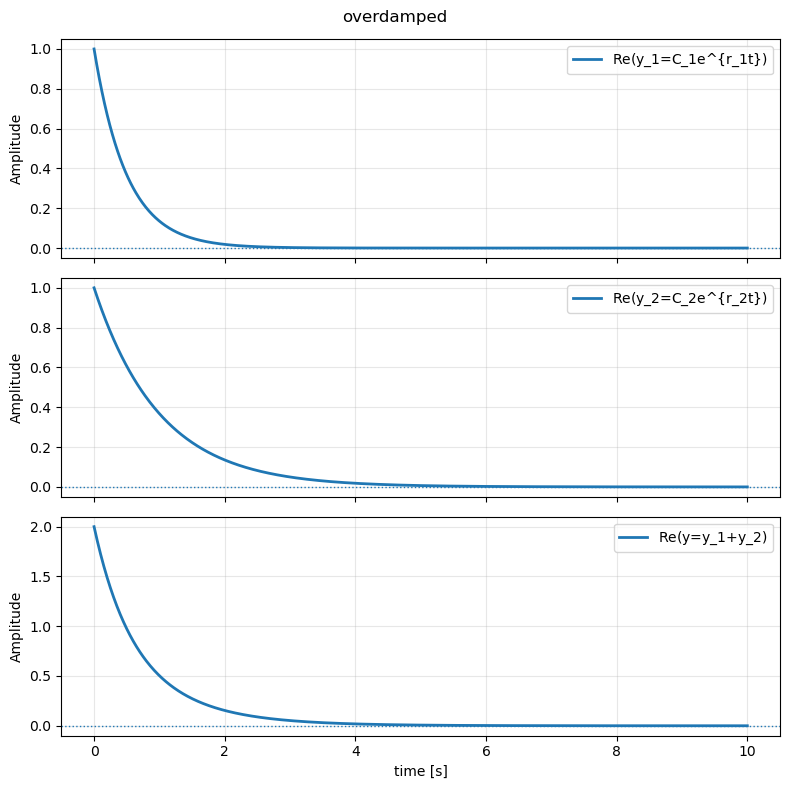

In [52]:
# overdamped
t = np.linspace(0, 10, 1000)

C1 = 1.
C2 = 1.
r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=3,
    c=2,
    C1=C1,
    C2=C2
)
print(r1,r2)
plot_exponential(t, r1, r2, C1, C2, title="overdamped")


-1.0 -1.0


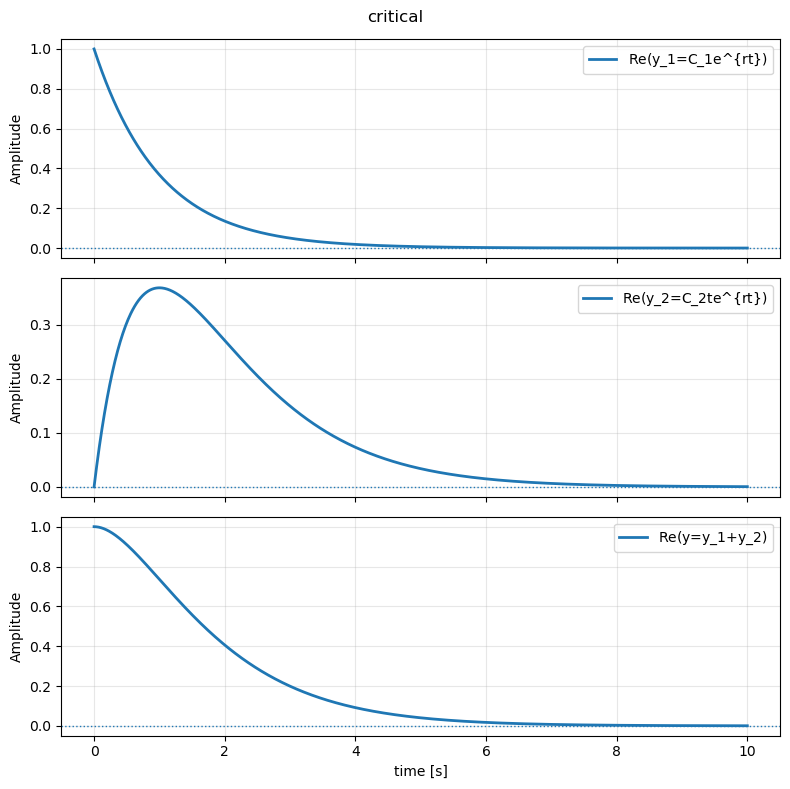

In [53]:
# critically damped
r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=2,
    c=1,
    C1=1,
    C2=1
)
print(r1, r2)
plot_exponential(t, r1, r2, 1, 1, title="critical")

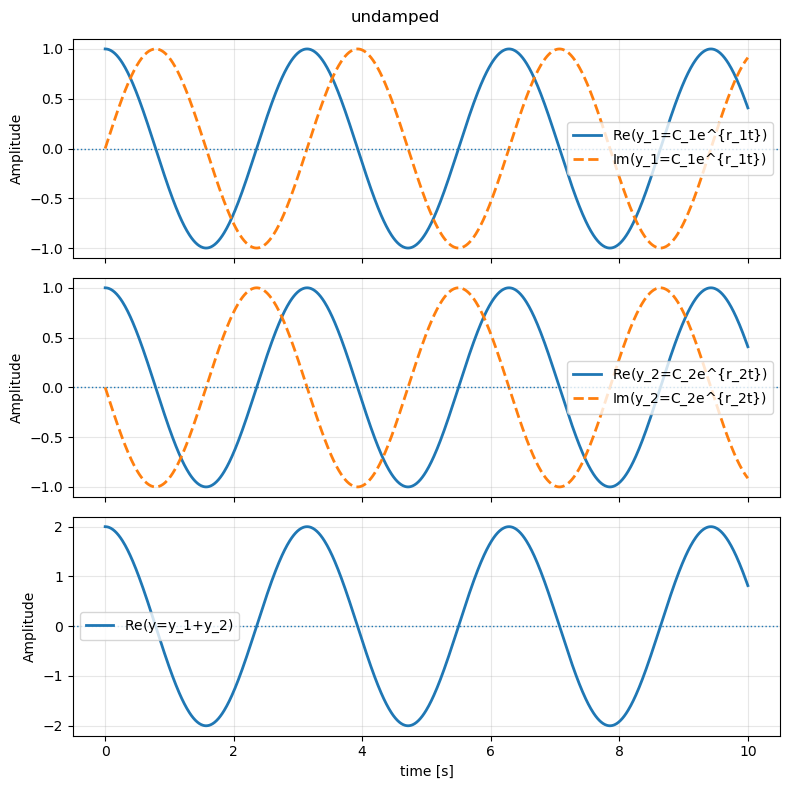

In [44]:
# undamped oscillator
r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=0,
    c=4,
    C1=1,
    C2=1
)

plot_exponential(t, r1, r2, 1, 1, title="undamped")

(-0.20000000000000007+1.98997487421324j) (-0.20000000000000007-1.98997487421324j)


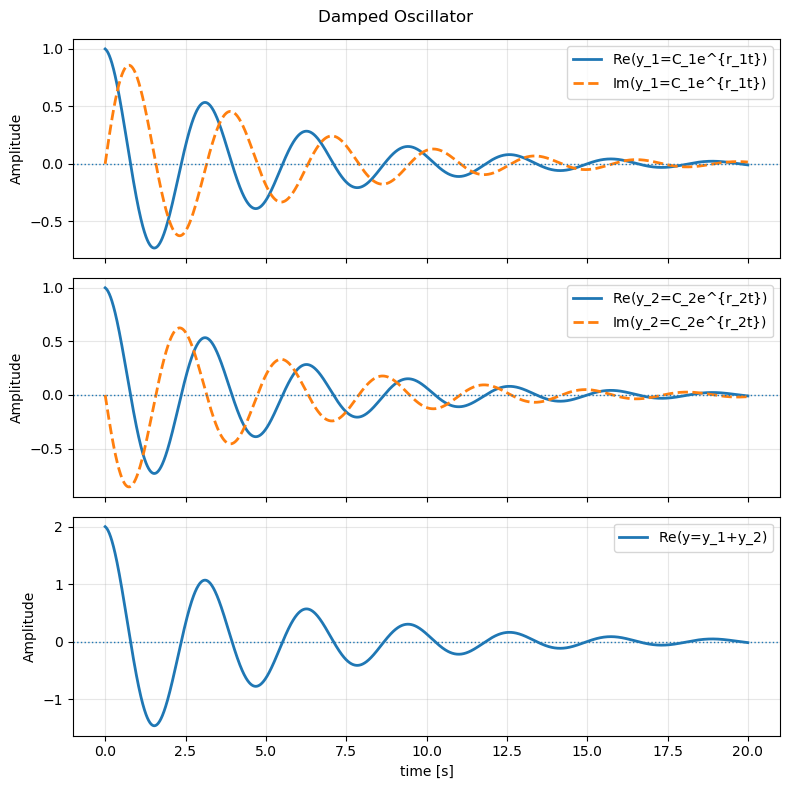

In [45]:
t = np.linspace(0, 20, 2000)

r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=0.4,
    c=4,
    C1=1,
    C2=1
)
print(r1, r2)
plot_exponential(
    t,
    r1,
    r2,
    1,
    1,
    title="Damped Oscillator"
)

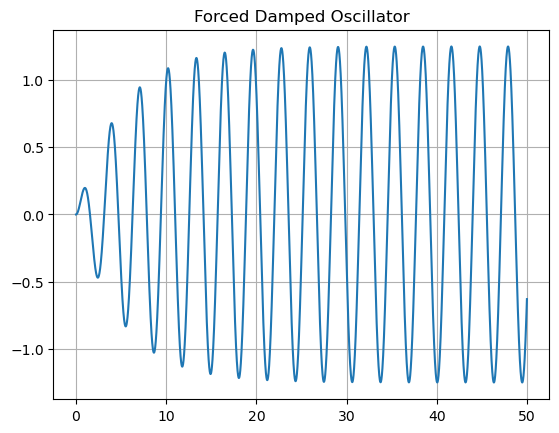

In [46]:
from scipy.integrate import solve_ivp
import numpy as np

def forced_oscillator(t, y, zeta=0.1, wn=2.0):
    x, xd = y

    forcing = np.cos(2*t)

    xdd = (
        forcing
        - 2*zeta*wn*xd
        - wn**2*x
    )

    return [xd, xdd]

t = np.linspace(0, 50, 5000)

sol = solve_ivp(
    forced_oscillator,
    [t[0], t[-1]],
    [0, 0],
    t_eval=t
)

plt.plot(t, sol.y[0])
plt.title("Forced Damped Oscillator")
plt.grid()
plt.show()

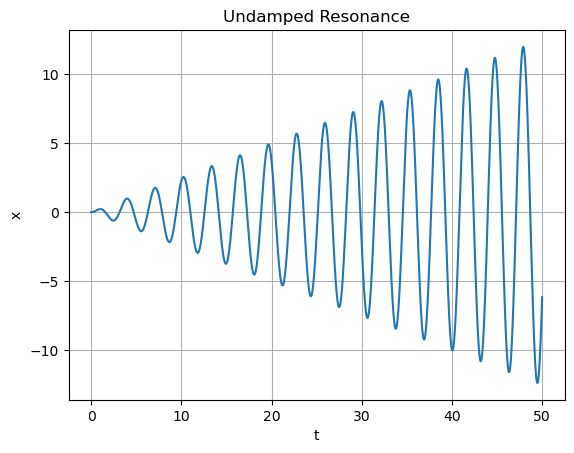

In [47]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


def resonant_oscillator(t, y):
    x, xd = y

    forcing = np.cos(2*t)

    xdd = forcing - 4*x

    return [xd, xdd]


t = np.linspace(0, 50, 5000)

sol = solve_ivp(
    resonant_oscillator,
    [0, 50],
    [0, 0],
    t_eval=t
)

plt.plot(t, sol.y[0])
plt.grid()
plt.title("Undamped Resonance")
plt.xlabel("t")
plt.ylabel("x")
plt.show()

Underdamped roots:
(-0.20000000000000007+1.98997487421324j) (-0.20000000000000007-1.98997487421324j)


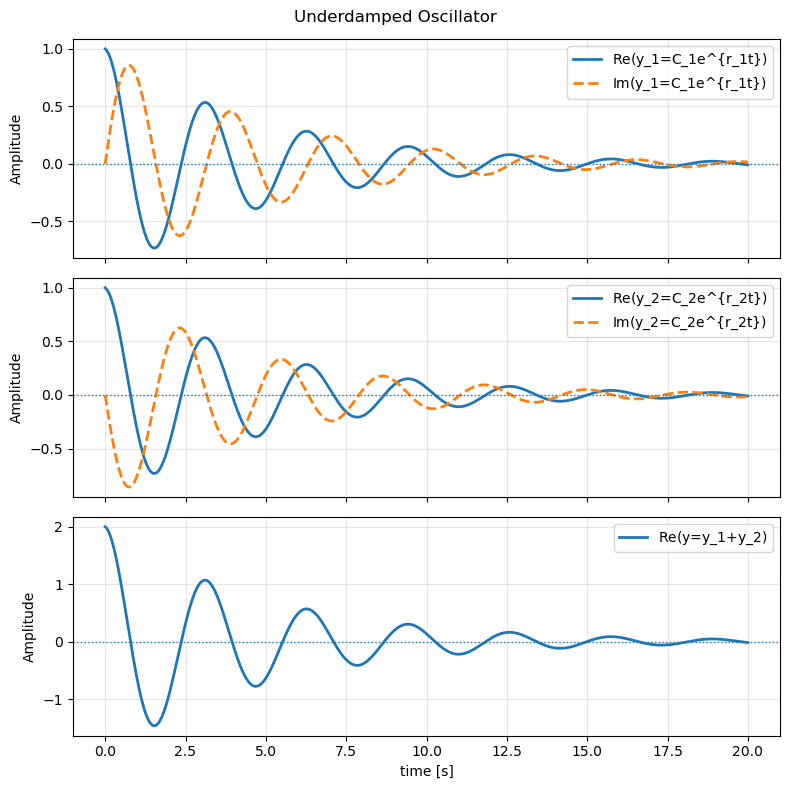

Critically damped roots:
-2.0 -2.0


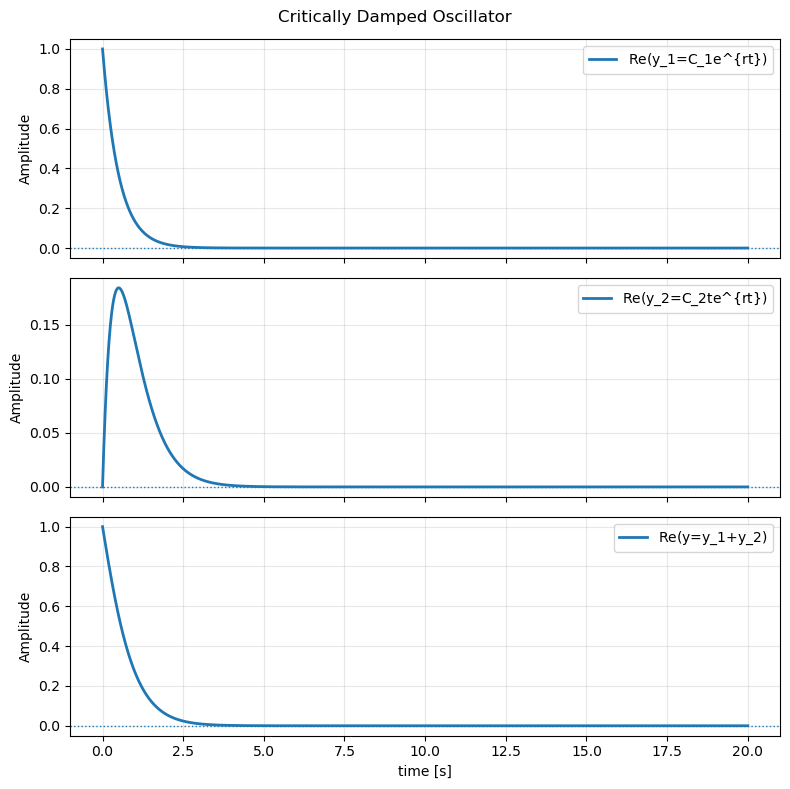

Overdamped roots:
-7.464101615137754 -0.5358983848622454


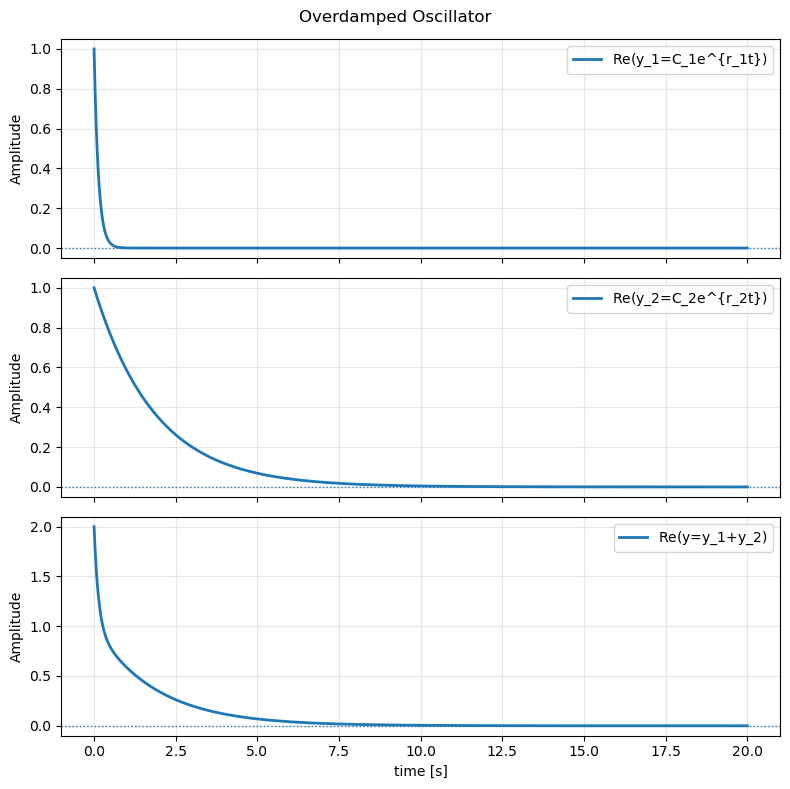

In [48]:
import numpy as np

t = np.linspace(0, 20, 2000)

# ------------------------------------------------------------
# 1. Underdamped
# D = b^2 - 4ac < 0
# Here: b = 0.4, a = 1, c = 4
# D = 0.16 - 16 < 0
# ------------------------------------------------------------

r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=0.4,
    c=4,
    C1=1,
    C2=1
)

print("Underdamped roots:")
print(r1, r2)

plot_exponential(
    t,
    r1,
    r2,
    C1=1,
    C2=1,
    title="Underdamped Oscillator"
)


# ------------------------------------------------------------
# 2. Critically damped
# D = b^2 - 4ac = 0
# Here: b = 4, a = 1, c = 4
# D = 16 - 16 = 0
# ------------------------------------------------------------

r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=4,
    c=4,
    C1=1,
    C2=1
)

print("Critically damped roots:")
print(r1, r2)

plot_exponential(
    t,
    r1,
    r2,
    C1=1,
    C2=1,
    title="Critically Damped Oscillator"
)


# ------------------------------------------------------------
# 3. Overdamped
# D = b^2 - 4ac > 0
# Here: b = 8, a = 1, c = 4
# D = 64 - 16 > 0
# ------------------------------------------------------------

r1, r2 = solve_2ndOrder_ODE(
    t=t,
    a=1,
    b=8,
    c=4,
    C1=1,
    C2=1
)

print("Overdamped roots:")
print(r1, r2)

plot_exponential(
    t,
    r1,
    r2,
    C1=1,
    C2=1,
    title="Overdamped Oscillator"
)

In [50]:
import numpy as np
import matplotlib.pyplot as plt


def solve_roots(a: float, b: float, c: float):
    D = b**2 - 4*a*c

    r1 = (-b + np.sqrt(D + 0j)) / (2*a)
    r2 = (-b - np.sqrt(D + 0j)) / (2*a)

    return r1, r2, D


def solve_coefficients(
    r1: complex,
    r2: complex,
    x0: float,
    v0: float,
    tol: float = 1e-12,
):
    """
    Solve coefficients from initial conditions.

    Distinct roots:
        x(t) = C1 exp(r1 t) + C2 exp(r2 t)

    Repeated root:
        x(t) = (C1 + C2 t) exp(r t)
    """

    repeated = np.isclose(r1, r2, atol=tol, rtol=tol)

    if repeated:
        r = r1

        C1 = x0
        C2 = v0 - r*C1

        return C1, C2, repeated

    A = np.array(
        [
            [1, 1],
            [r1, r2]
        ],
        dtype=complex
    )

    y = np.array([x0, v0], dtype=complex)

    C1, C2 = np.linalg.solve(A, y)

    return C1, C2, repeated


def evaluate_solution(
    t: np.ndarray,
    r1: complex,
    r2: complex,
    C1: complex,
    C2: complex,
    repeated: bool,
):
    if repeated:
        r = r1
        x = (C1 + C2*t) * np.exp(r*t)
        return x

    x = C1*np.exp(r1*t) + C2*np.exp(r2*t)
    return x


def plot_damped_case(
    t: np.ndarray,
    a: float,
    b: float,
    c: float,
    x0: float = 1.0,
    v0: float = 0.0,
    title: str | None = None,
):
    r1, r2, D = solve_roots(a, b, c)

    C1, C2, repeated = solve_coefficients(
        r1=r1,
        r2=r2,
        x0=x0,
        v0=v0
    )

    x = evaluate_solution(
        t=t,
        r1=r1,
        r2=r2,
        C1=C1,
        C2=C2,
        repeated=repeated
    )

    # For real initial conditions and real ODE coefficients,
    # the physical displacement should be real up to roundoff.
    x_real = np.real_if_close(x, tol=1000)

    plt.figure(figsize=(8, 4), dpi=120)

    plt.plot(
        t,
        np.real(x_real),
        linewidth=2,
        label=r"$x(t)$"
    )

    plt.axhline(
        0,
        linestyle=":",
        linewidth=1
    )

    plt.xlabel("time [s]")
    plt.ylabel("displacement")
    plt.grid(True, alpha=0.3)

    if title is not None:
        plt.title(title)

    plt.legend()
    plt.tight_layout()
    plt.show()

    print(title)
    print("D  =", D)
    print("r1 =", r1)
    print("r2 =", r2)
    print("C1 =", C1)
    print("C2 =", C2)
    print()

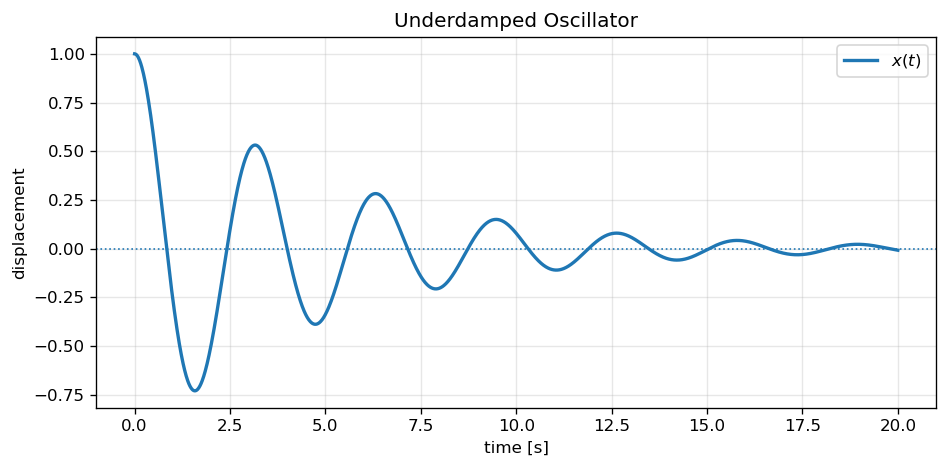

Underdamped Oscillator
D  = -15.84
r1 = (-0.2+1.98997487421324j)
r2 = (-0.2-1.98997487421324j)
C1 = (0.5-0.050251890762960605j)
C2 = (0.5+0.050251890762960605j)



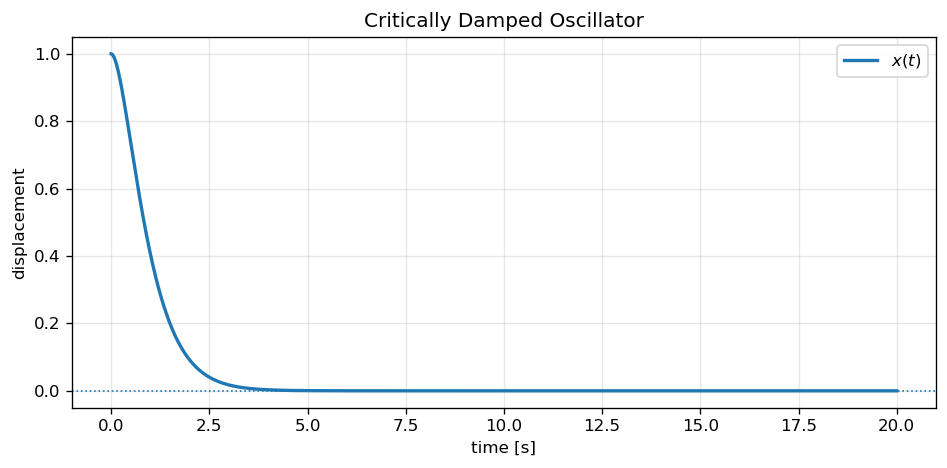

Critically Damped Oscillator
D  = 0.0
r1 = (-2+0j)
r2 = (-2+0j)
C1 = 1.0
C2 = (2+0j)



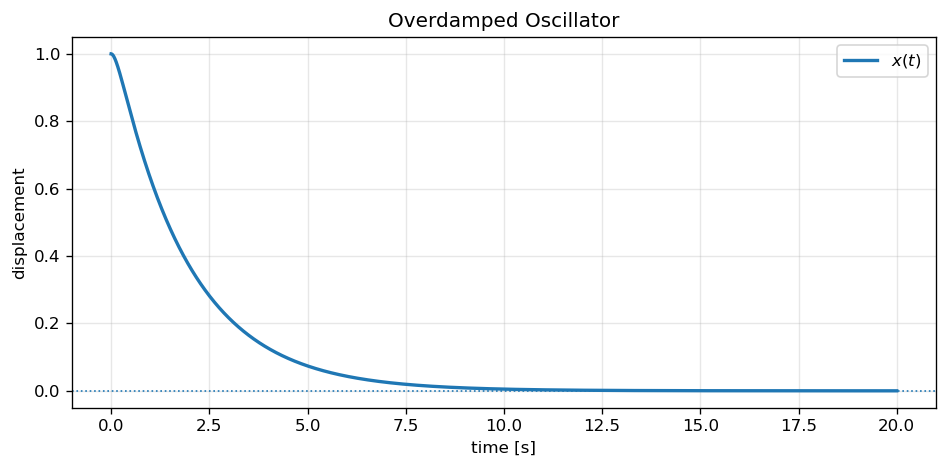

Overdamped Oscillator
D  = 48.0
r1 = (-0.5358983848622456+0j)
r2 = (-7.464101615137754+0j)
C1 = (1.0773502691896257+0j)
C2 = (-0.0773502691896258-0j)



In [51]:
t = np.linspace(0, 20, 2000)

cases = [
    {
        "title": "Underdamped Oscillator",
        "a": 1,
        "b": 0.4,
        "c": 4,
    },
    {
        "title": "Critically Damped Oscillator",
        "a": 1,
        "b": 4.0,
        "c": 4,
    },
    {
        "title": "Overdamped Oscillator",
        "a": 1,
        "b": 8.0,
        "c": 4,
    },
]

for case in cases:
    plot_damped_case(
        t=t,
        a=case["a"],
        b=case["b"],
        c=case["c"],
        x0=1.0,
        v0=0.0,
        title=case["title"]
    )